# Hands-on Medical Multimodal AI
## General CLIP -> Tiny Medical Fine-Tuning -> BiomedCLIP

**Task:** medical image-text retrieval  
**Fine-tuning data:** a small public IU X-Ray / NLMCXR image-report subset  
**Evaluation data:** a held-out chest-radiograph subset from the ROCOv2 **test** split  
**Recommended runtime:** Google Colab GPU  
**Target duration:** 60 minutes (models/datasets should be pre-cached before the live session)

> **Teaching/research only.** This notebook is not a clinical diagnostic system.

### The story of the practical

1. **General CLIP:** How well does a general vision-language model retrieve medical images?
2. **Tiny domain adaptation:** Can we demonstrate medical fine-tuning with only a small number of image-report pairs?
3. **BiomedCLIP:** How does a purpose-built biomedical vision-language model behave on the same held-out test set?
4. **Interactive ROCOv2 retrieval:** After the comparison, use BiomedCLIP for text-to-image and image-to-text Top-K search over a broader ROCOv2 gallery.

We are **not** trying to reproduce the training of BiomedCLIP. The small fine-tuning stage is intentionally a teaching demonstration.


## Session Goals

Before we begin, remember the core objectives of this session:

1.  **General CLIP Baseline:** Understand how a general-purpose model performs on medical data.
2.  **Tiny Domain Adaptation:** See the mechanics of fine-tuning with a very small medical dataset.
3.  **BiomedCLIP Comparison:** Evaluate a purpose-built biomedical model.
4.  **Interactive Retrieval:** Experience cross-modal search on a broader dataset.

## 60-minute session map

| Time | Activity | Main idea |
|---|---|---|
| 0-5 min | Scenario + CLIP idea | Images and text can share an embedding space |
| 5-12 min | Explore IU X-Ray + ROCOv2 samples | See the real image-text pairs and separate training from test data |
| 12-19 min | General CLIP baseline | Encode, normalize, retrieve, record Recall@K |
| 19-33 min | Tiny medical fine-tuning | Contrastive loss + backpropagation + optimizer |
| 33-40 min | Re-evaluate CLIP | Did small domain adaptation change retrieval? |
| 40-49 min | BiomedCLIP | Biomedical dual-encoder retrieval on same test set |
| 49-54 min | Compare three stages | General model vs adapted model vs biomedical model |
| 54-60 min | Interactive ROCOv2 retrieval | Text -> Top-K images and image -> Top-K captions |

### What attendees should write themselves

Attendees should type the key lines for:

- image/text encoding and normalization;
- similarity matrix computation;
- text-to-image and image-to-text Top-K retrieval;
- symmetric contrastive loss;
- `loss.backward()` and `optimizer.step()`;
- Recall@K hit calculation.


# Part A - Setup

## 1. Install libraries

BiomedCLIP's published OpenCLIP example uses an older OpenCLIP/Transformers environment. In Colab, installing these versions may produce warnings about unrelated preinstalled packages. If imports fail after installation, restart the runtime once and continue from the imports cell.


In [ ]:
%pip install -q "open_clip_torch==2.23.0" "transformers==4.35.2" "datasets>=2.19,<4" "huggingface_hub<1.0" matplotlib pandas Pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.5/123.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.40.0 requires huggi

## 2. Imports, reproducibility, and device


In [ ]:
import gc
import itertools
import math
import re
import time
import textwrap
from pathlib import Path

from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
import open_clip
from open_clip import create_model_from_pretrained, get_tokenizer

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type == "cpu":
    print("CPU mode detected. The notebook will work, but fine-tuning will be much slower.")
    print("For a 60-minute live tutorial, use a Colab GPU runtime.")


/usr/local/lib/python3.13/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.13/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Device: cpu
CPU mode detected. The notebook will work, but fine-tuning will be much slower.
For a 60-minute live tutorial, use a Colab GPU runtime.


## 3. Tutorial configuration

The defaults are intentionally small. They are chosen for a live demonstration, **not** for obtaining state-of-the-art medical retrieval results.


In [ ]:
# Tiny fine-tuning subset from IU X-Ray / NLMCXR
FT_SAMPLES = 64

# Held-out ROCOv2 chest-radiograph test subset
TEST_SAMPLES = 32

# Fine-tuning settings
FT_BATCH_SIZE = 8
FT_EPOCHS = 2
FT_LR = 1e-5
FT_WEIGHT_DECAY = 0.01

# Retrieval cutoffs
RECALL_K = [1, 5, 10]

print({
    "fine_tune_pairs": FT_SAMPLES,
    "test_pairs": TEST_SAMPLES,
    "batch_size": FT_BATCH_SIZE,
    "epochs": FT_EPOCHS,
    "learning_rate": FT_LR,
})

{'fine_tune_pairs': 64, 'test_pairs': 32, 'batch_size': 8, 'epochs': 2, 'learning_rate': 1e-05}


## Configuration Choices

These parameters (`FT_SAMPLES`, `TEST_SAMPLES`, etc.) are intentionally kept small for a quick demonstration. In a real-world scenario, you would use much larger datasets and potentially more epochs for fine-tuning.

# Part B - Data

## 4. Fine-tuning data: small IU X-Ray / NLMCXR subset

For the live fine-tuning demonstration we use a public Hugging Face mirror of the IU X-Ray / NLMCXR collection: `Fakhraddin/NLMCXR`.

The mirror exposes three convenient fields:

- `image`: chest radiograph as a PIL image;
- `text`: associated radiology-report text;
- `path`: source image path.

Many studies contain more than one radiographic view with the same report. For this small tutorial we keep **one image per study** to reduce near-duplicate text pairs.

> The mirror is used for convenience in a teaching notebook. If you redistribute data or use it in a formal study, verify the source dataset terms and provenance separately.


In [ ]:
IU_DATASET_ID = "Fakhraddin/NLMCXR"


def clean_iu_text(text):
    # The public mirror contains de-identification placeholders such as XXXX.
    text = re.sub(r"\bXXXX\b", "", str(text))
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def iu_study_key(path):
    """Collapse multiple views from the same study to one key."""
    stem = Path(path).stem
    # Example: CXR10_IM-0002-1001 -> CXR10_IM-0002
    return stem.rsplit("-", 1)[0]


print(f"Streaming {FT_SAMPLES} unique IU X-Ray studies...")
iu_stream = load_dataset(IU_DATASET_ID, split="train", streaming=True)

ft_rows = []
seen_studies = set()

for row in iu_stream:
    key = iu_study_key(row["path"])
    if key in seen_studies:
        continue

    text = clean_iu_text(row["text"])
    if len(text) < 20:
        continue

    seen_studies.add(key)
    ft_rows.append({
        "study_id": key,
        "path": row["path"],
        "image": row["image"].convert("RGB"),
        "text": text,
    })

    if len(ft_rows) >= FT_SAMPLES:
        break

if len(ft_rows) < FT_SAMPLES:
    raise RuntimeError(f"Only loaded {len(ft_rows)} unique IU X-Ray studies.")

ft_images = [r["image"] for r in ft_rows]
ft_texts = [r["text"] for r in ft_rows]

print("Fine-tuning pairs loaded:", len(ft_rows))
print("Example text:", ft_texts[0][:300])

Streaming 64 unique IU X-Ray studies...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/642 [00:00<?, ?B/s]

Fine-tuning pairs loaded: 64
Example text: Normal chest x-. The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no of a pleural effusion. There is no evidence of pneumothorax.


## Data Cleaning

Notice the `clean_iu_text` function. This is a common step in NLP tasks to handle specific dataset artifacts, like de-identification placeholders (`XXXX`).

## 5. Evaluation data: held-out ROCOv2 chest radiographs

All three models are evaluated on the **same ROCOv2 test examples**. No selected ROCOv2 test image is used for fine-tuning.

ROCOv2's Hugging Face representation exposes `image`, `image_id`, `caption`, and `cui`. For a compact chest-X-ray experiment, we select test records whose captions contain an X-ray/radiograph term and a chest/lung/pleural/cardiac term.

This is a transparent **teaching heuristic**, not a clinically validated modality classifier.


In [ ]:
ROCO_DATASET_ID = "eltorio/ROCOv2-radiology"


def is_xray_caption(caption):
    c = str(caption).lower()
    terms = ["x-ray", "x ray", "xray", "radiograph", "radiographic"]
    return any(t in c for t in terms)


def is_chest_caption(caption):
    c = str(caption).lower()
    terms = [
        "chest", "thorax", "thoracic", "lung", "lungs", "pulmonary",
        "pleural", "pneumothorax", "cardiac", "cardiomegaly", "mediast"
    ]
    return any(t in c for t in terms)


def collect_roco_test_xrays(target_n=32, require_chest=True):
    stream = load_dataset(ROCO_DATASET_ID, split="test", streaming=True)
    selected = []

    for row in stream:
        caption = row["caption"]
        keep = is_xray_caption(caption)
        if require_chest:
            keep = keep and is_chest_caption(caption)

        if keep:
            selected.append(row)

        if len(selected) >= target_n:
            break

    return selected


print(f"Selecting {TEST_SAMPLES} held-out ROCOv2 chest-radiograph examples...")
test_rows = collect_roco_test_xrays(TEST_SAMPLES, require_chest=True)

# Robust fallback if the caption heuristic finds too few chest-specific rows.
if len(test_rows) < TEST_SAMPLES:
    print("Chest-specific heuristic returned too few examples; falling back to any X-ray/radiograph caption.")
    test_rows = collect_roco_test_xrays(TEST_SAMPLES, require_chest=False)

if len(test_rows) < TEST_SAMPLES:
    raise RuntimeError(f"Only found {len(test_rows)} suitable ROCOv2 test examples.")

test_images = [r["image"].convert("RGB") for r in test_rows]
test_captions = [r["caption"] for r in test_rows]
test_ids = [r["image_id"] for r in test_rows]

print("Held-out test pairs:", len(test_rows))
print("First test caption:", test_captions[0])

Selecting 32 held-out ROCOv2 chest-radiograph examples...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Held-out test pairs: 32
First test caption: Chest radiography shows aneurysm as protruding mass.


## Highlight: ROCOv2 Selection

The `is_xray_caption` and `is_chest_caption` functions demonstrate a pragmatic heuristic to select relevant examples for this tutorial. In a formal research setting, this selection process would be much more rigorous and clinically validated.

# Part C - Know Your Data Before the Models

## 6. Explore the datasets before any CLIP experiment

Before loading or fine-tuning a model, first inspect the **actual image-text pairs**.

We use two different datasets for two different purposes:

| Dataset | Role | Image | Paired text | Used to update weights? |
|---|---|---|---|---|
| **IU X-Ray / NLMCXR** | Fine-tuning | Chest radiograph | Radiology report | **Yes** |
| **ROCOv2 test subset** | Evaluation | Selected radiograph | Biomedical figure caption | **No** |

The important separation is:

```text
IU X-Ray / NLMCXR
64 image-report pairs
        |
        v
FINE-TUNING DATA
(model learns from these)

ROCOv2 TEST
32 image-caption pairs
        |
        v
HELD-OUT EVALUATION DATA
(model must not learn from these)
```

### What attendees should notice

- The two datasets both contain medical images paired with text, but the **text styles are different**.
- IU X-Ray text resembles a radiology report.
- ROCOv2 text resembles a figure caption from biomedical literature.
- Fine-tuning and testing on different datasets makes the domain-adaptation demonstration more meaningful.


## 7. Look at several IU X-Ray / NLMCXR fine-tuning pairs

The following cell displays **six real fine-tuning samples**. Each image is paired with report text that will later be supplied to CLIP during the tiny domain-adaptation stage.

Only a shortened version of the report is placed above each image so the figure remains readable. The complete report is still stored in `ft_rows[i]["text"]` and is used by the training pipeline.


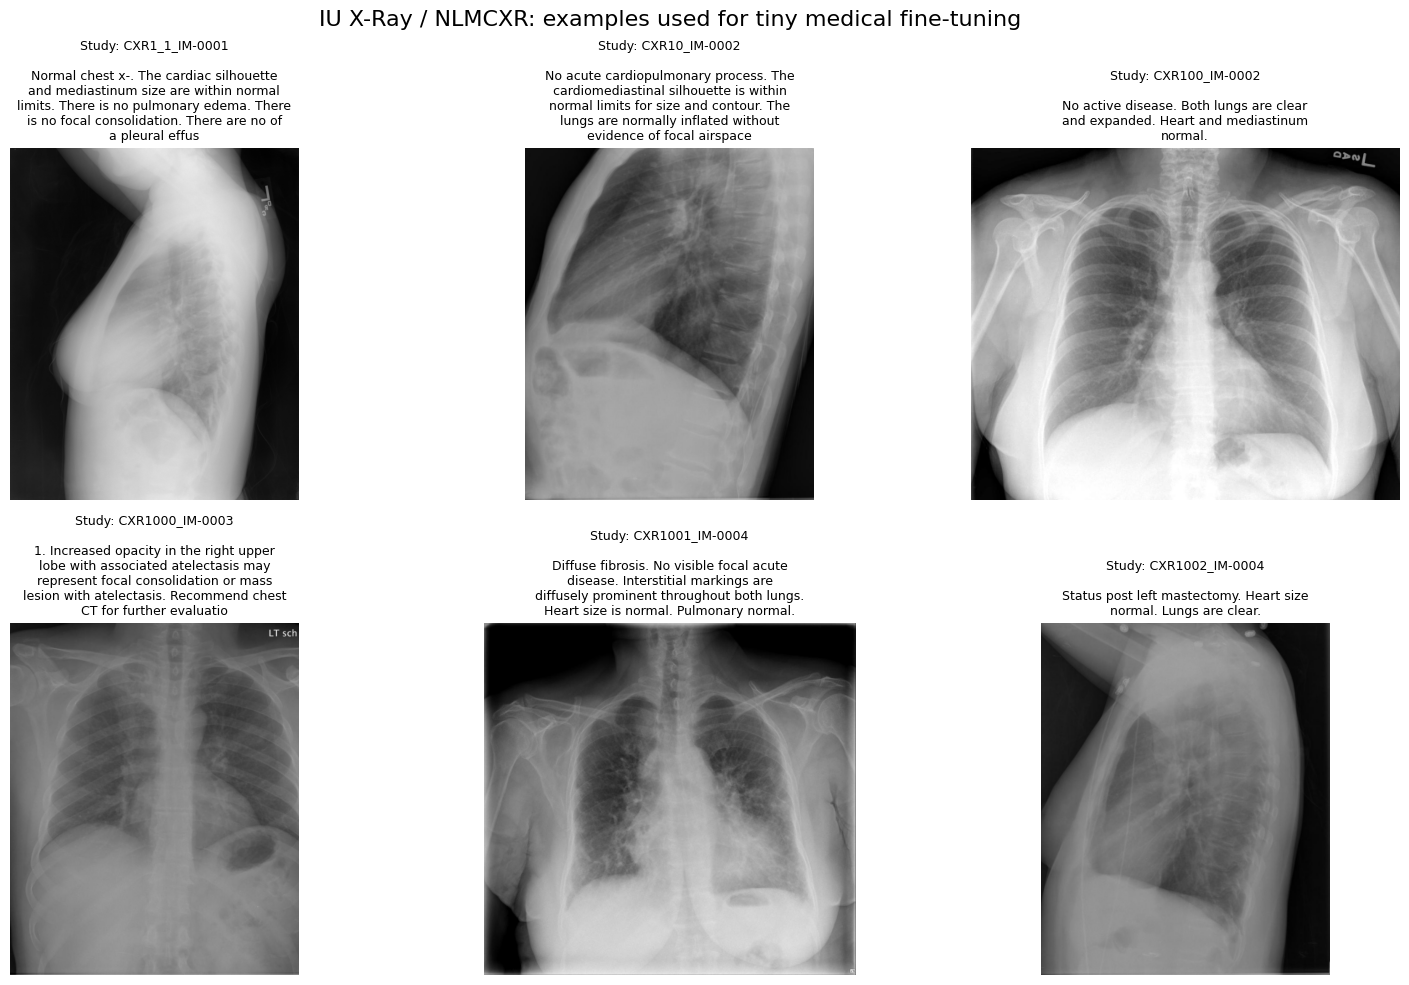

In [ ]:
N_IU_SHOW = min(6, len(ft_rows))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = np.atleast_1d(axes).flatten()

for ax in axes:
    ax.axis("off")

for i in range(N_IU_SHOW):
    sample = ft_rows[i]
    axes[i].imshow(sample["image"])
    axes[i].axis("off")

    short_text = textwrap.fill(sample["text"][:180], width=42)
    axes[i].set_title(
        f"Study: {sample['study_id']}\n\n{short_text}",
        fontsize=9,
    )

plt.suptitle(
    "IU X-Ray / NLMCXR: examples used for tiny medical fine-tuning",
    fontsize=16,
)
plt.tight_layout()
plt.show()


## 8. Read complete IU X-Ray report examples

A CLIP-style model is not being trained on simple class labels such as `pneumonia` or `normal`. It receives **natural-language medical text paired with an image**.

Read a few complete report strings before moving on.


In [ ]:
N_FULL_REPORTS = min(3, len(ft_rows))

for i in range(N_FULL_REPORTS):
    sample = ft_rows[i]
    print("=" * 100)
    print(f"IU X-Ray sample {i + 1}")
    print("Study ID  :", sample["study_id"])
    print("Image path:", sample["path"])
    print("\nAssociated radiology report:")
    print(sample["text"])
    print()


IU X-Ray sample 1
Study ID  : CXR1_1_IM-0001
Image path: /content/IU-XRay/images/CXR1_1_IM-0001-3001.png

Associated radiology report:
Normal chest x-. The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no of a pleural effusion. There is no evidence of pneumothorax.

IU X-Ray sample 2
Study ID  : CXR10_IM-0002
Image path: /content/IU-XRay/images/CXR10_IM-0002-1001.png

Associated radiology report:
No acute cardiopulmonary process. The cardiomediastinal silhouette is within normal limits for size and contour. The lungs are normally inflated without evidence of focal airspace disease, pleural effusion, or pneumothorax. Stable calcified granuloma within the right upper lung. No acute bone abnormality..

IU X-Ray sample 3
Study ID  : CXR100_IM-0002
Image path: /content/IU-XRay/images/CXR100_IM-0002-1001.png

Associated radiology report:
No active disease. Both lungs are clear and expanded. Heart and 

## Highlight: Text Style Differences

Take a moment to read these full IU X-Ray reports. Contrast their style with what you expect from general image captions. This difference is crucial for understanding the impact of domain adaptation.

## 9. Summarize the IU X-Ray text used for fine-tuning

Radiology reports vary in length. That matters because a text encoder has a maximum context length; sufficiently long reports may be truncated by a general CLIP tokenizer.

This cell gives a small table and basic report-length statistics.


In [ ]:
iu_preview = pd.DataFrame([
    {
        "study_id": row["study_id"],
        "report_chars": len(row["text"]),
        "report_preview": row["text"][:220],
    }
    for row in ft_rows[:8]
])

pd.set_option("display.max_colwidth", 220)
display(iu_preview)

report_lengths = [len(text) for text in ft_texts]
print("Fine-tuning pairs       :", len(ft_texts))
print("Shortest report (chars) :", min(report_lengths))
print("Longest report (chars)  :", max(report_lengths))
print("Average report (chars)  :", f"{np.mean(report_lengths):.1f}")


,study_id,report_chars,report_preview
0,CXR1_1_IM-0001,222,Normal chest x-. The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no of a pleural effusion. There is no evidence of pneumot...
1,CXR10_IM-0002,307,"No acute cardiopulmonary process. The cardiomediastinal silhouette is within normal limits for size and contour. The lungs are normally inflated without evidence of focal airspace disease, pleural effusion, or pneumo..."
2,CXR100_IM-0002,83,No active disease. Both lungs are clear and expanded. Heart and mediastinum normal.
3,CXR1000_IM-0003,606,1. Increased opacity in the right upper lobe with associated atelectasis may represent focal consolidation or mass lesion with atelectasis. Recommend chest CT for further evaluation. 2. opacity overlying the left 5th...
4,CXR1001_IM-0004,158,Diffuse fibrosis. No visible focal acute disease. Interstitial markings are diffusely prominent throughout both lungs. Heart size is normal. Pulmonary normal.
5,CXR1002_IM-0004,64,Status post left mastectomy. Heart size normal. Lungs are clear.
6,CXR1003_IM-0005,602,1. Retrocardiac soft tissue density. The appearance suggests hiatal hernia. 2. left base bandlike opacity. The appearance suggests atelectasis. Heart size and pulmonary vascularity appear within normal limits. Retroc...
7,CXR1004_IM-0005,370,"No acute cardiopulmonary disease. The heart, pulmonary and mediastinum are within normal limits. There is no pleural effusion or pneumothorax. There is no focal air space opacity to suggest a pneumonia. The aorta is ..."


Fine-tuning pairs       : 64
Shortest report (chars) : 35
Longest report (chars)  : 724
Average report (chars)  : 280.1


## 10. Look at several held-out ROCOv2 evaluation pairs

Now inspect examples from the **evaluation dataset**. These images and captions are not used to update CLIP's weights.

The model will later be asked to retrieve these images from their corresponding text and vice versa.


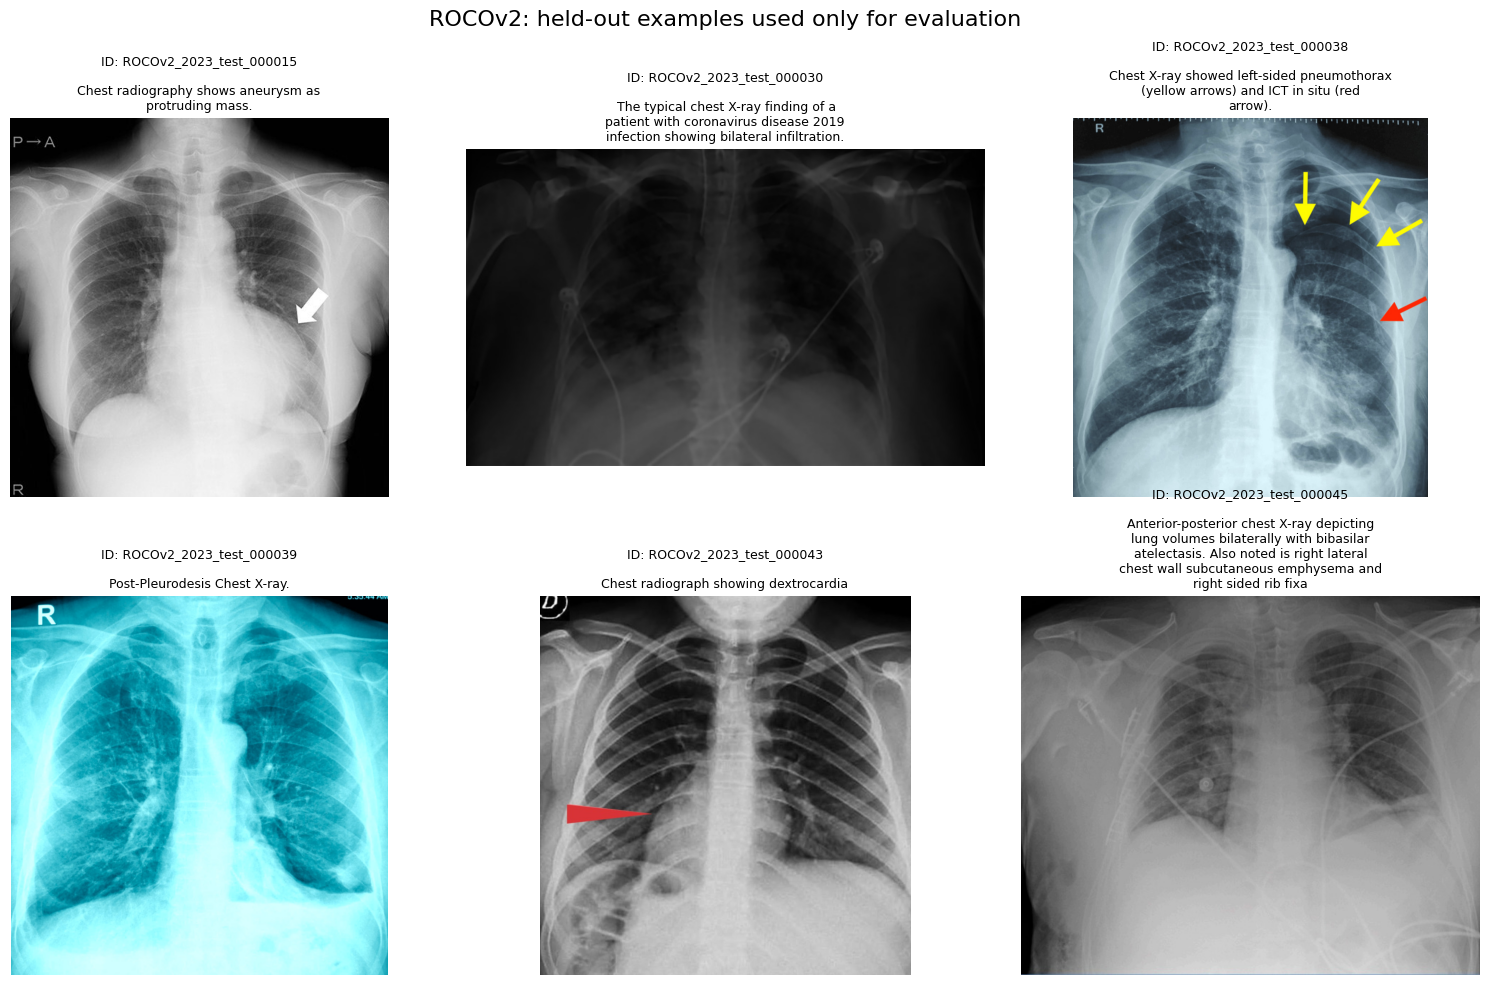

In [ ]:
N_ROCO_SHOW = min(6, len(test_rows))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = np.atleast_1d(axes).flatten()

for ax in axes:
    ax.axis("off")

for i in range(N_ROCO_SHOW):
    image = test_images[i]
    caption = test_captions[i]
    image_id = test_ids[i]

    axes[i].imshow(image)
    axes[i].axis("off")

    short_caption = textwrap.fill(caption[:180], width=42)
    axes[i].set_title(
        f"ID: {image_id}\n\n{short_caption}",
        fontsize=9,
    )

plt.suptitle(
    "ROCOv2: held-out examples used only for evaluation",
    fontsize=16,
)
plt.tight_layout()
plt.show()


## 11. Inspect the ROCOv2 captions as a table

Notice how these captions may differ stylistically from IU X-Ray radiology reports even though both are medical text.


In [ ]:
roco_preview = pd.DataFrame([
    {
        "image_id": test_ids[i],
        "caption_chars": len(test_captions[i]),
        "caption": test_captions[i],
    }
    for i in range(min(8, len(test_rows)))
])

pd.set_option("display.max_colwidth", 220)
display(roco_preview)


,image_id,caption_chars,caption
0,ROCOv2_2023_test_000015,52,Chest radiography shows aneurysm as protruding mass.
1,ROCOv2_2023_test_000030,117,The typical chest X-ray finding of a patient with coronavirus disease 2019 infection showing bilateral infiltration.
2,ROCOv2_2023_test_000038,87,Chest X-ray showed left-sided pneumothorax (yellow arrows) and ICT in situ (red arrow).
3,ROCOv2_2023_test_000039,29,Post-Pleurodesis Chest X-ray.
4,ROCOv2_2023_test_000043,37,Chest radiograph showing dextrocardia
5,ROCOv2_2023_test_000045,194,Anterior-posterior chest X-ray depicting lung volumes bilaterally with bibasilar atelectasis. Also noted is right lateral chest wall subcutaneous emphysema and right sided rib fixation hardware.
6,ROCOv2_2023_test_000067,150,Chest radiograph during initial presentation demonstrating complete opacification of the right hemithorax with mediastinal shift to the opposite side.
7,ROCOv2_2023_test_000068,177,Chest radiograph following completion of t-PA and DNase therapy demonstrates marked improvement in right-sided opacities.t-PA: tissue plasminogen activator; DNase: dornase alfa.


## 12. Compare the two datasets side by side

This table is the key dataset-design slide for the tutorial. Keep the distinction clear before introducing CLIP.


In [ ]:
dataset_comparison = pd.DataFrame({
    "Property": [
        "Role in tutorial",
        "Selected examples",
        "Image domain",
        "Text type",
        "Changes CLIP weights?",
        "Used for held-out evaluation?",
    ],
    "IU X-Ray / NLMCXR": [
        "Tiny fine-tuning",
        FT_SAMPLES,
        "Chest radiographs",
        "Radiology reports",
        "Yes",
        "No",
    ],
    "ROCOv2": [
        "Held-out testing",
        TEST_SAMPLES,
        "Selected chest radiograph / X-ray examples",
        "Biomedical figure captions",
        "No",
        "Yes",
    ],
})

display(dataset_comparison)


,Property,IU X-Ray / NLMCXR,ROCOv2
0,Role in tutorial,Tiny fine-tuning,Held-out testing
1,Selected examples,64,32
2,Image domain,Chest radiographs,Selected chest radiograph / X-ray examples
3,Text type,Radiology reports,Biomedical figure captions
4,Changes CLIP weights?,Yes,No
5,Used for held-out evaluation?,No,Yes



Before showing any model code, ask:

1. Which dataset will **change CLIP's weights**?  
   **Answer:** IU X-Ray / NLMCXR.
2. Which dataset is used only to **measure generalization**?  
   **Answer:** the held-out ROCOv2 test subset.
3. Why do we not report post-fine-tuning performance on the same 64 IU X-Ray pairs?  
   **Answer:** the model has already learned from them, so this would risk memorization/data leakage and an overly optimistic result.
4. Are IU X-Ray reports and ROCOv2 captions written in exactly the same style?  
   **Answer:** no. This text-domain shift is one reason the tiny fine-tuning stage may improve, stay similar, or hurt ROCOv2 retrieval.

Only after this discussion should the class move to CLIP.


# Part D - Shared retrieval and evaluation helpers

## 13. Recall@K

For an evaluation subset with `N` paired image-caption examples, caption `i` is treated as paired with image `i`. Recall@K asks whether that paired target appears among the Top-K retrieved results.

This is an **exact-pair benchmark**. A different medically relevant image may still be counted as an error.


In [ ]:
def recall_at_k(similarity_matrix, k):
    k = min(k, similarity_matrix.shape[1])
    topk_indices = similarity_matrix.topk(k, dim=1).indices
    targets = torch.arange(similarity_matrix.shape[0]).unsqueeze(1)

    # STUDENT TASK: correct target i should occur somewhere in row i's Top-K.
    hits = (topk_indices == targets).any(dim=1)
    return hits.float().mean().item()


def compute_retrieval_metrics(image_embeddings, text_embeddings, ks=(1, 5, 10)):
    # Rows = text queries, columns = candidate images.
    sim_t2i = text_embeddings @ image_embeddings.T
    sim_i2t = sim_t2i.T

    result = {}
    for k in ks:
        result[f"T2I_R@{k}"] = recall_at_k(sim_t2i, k)
        result[f"I2T_R@{k}"] = recall_at_k(sim_i2t, k)

    paired_similarity = sim_t2i.diag().mean().item()
    result["mean_paired_similarity"] = paired_similarity
    return result, sim_t2i


def metrics_row(model_name, metrics):
    row = {"Model": model_name}
    row.update(metrics)
    return row

# Part E - Stage 1: General CLIP baseline

## 14. Why start with general CLIP?

We first ask a simple question:

> **How well does a general-purpose image-text model work on an unseen medical retrieval set before any medical adaptation?**

We use OpenAI CLIP ViT-B/16 through OpenCLIP.


In [ ]:
CLIP_MODEL = "ViT-B-16"
CLIP_PRETRAINED = "openai"

print("Loading general CLIP...")
t0 = time.perf_counter()

clip_model, clip_preprocess_train, clip_preprocess_val = open_clip.create_model_and_transforms(
    CLIP_MODEL,
    pretrained=CLIP_PRETRAINED,
)
clip_tokenizer = open_clip.get_tokenizer(CLIP_MODEL)
clip_model = clip_model.to(device)
clip_model.eval()

print(f"General CLIP loaded in {time.perf_counter() - t0:.1f} s")

Loading general CLIP...


100%|████████████████████████████████████████| 351M/351M [00:03<00:00, 113MiB/s]


General CLIP loaded in 8.2 s


## Highlight: General CLIP Baseline

This is our starting point. We're asking: *how well does a model trained on general internet data perform on specialized medical content?* This baseline helps us appreciate the value of domain-specific adaptation.

## 15. Encode images and text

### STUDENT TASK

Ask attendees to type/identify the four conceptually important operations:

```python
features = model.encode_image(batch_tensor)
features = F.normalize(features.float(), dim=-1)

features = model.encode_text(tokens)
features = F.normalize(features.float(), dim=-1)
```

The rest is batching boilerplate.


## Highlight: Encoding Process

**STUDENT TASK:** Pay close attention to the `encode_clip_images` and `encode_clip_texts` functions. Identify the four core lines that perform the encoding and normalization. These are fundamental to how CLIP works!

In [ ]:
@torch.inference_mode()
def encode_clip_images(model, preprocess, image_list, batch_size=16):
    model.eval()
    batches = []

    for start in range(0, len(image_list), batch_size):
        batch_images = image_list[start:start + batch_size]
        batch_tensor = torch.stack([preprocess(img) for img in batch_images]).to(device)

        # Core attendee-written line 1
        features = model.encode_image(batch_tensor)
        # Core attendee-written line 2
        features = F.normalize(features.float(), dim=-1)
        batches.append(features.cpu())

    return torch.cat(batches, dim=0)


@torch.inference_mode()
def encode_clip_texts(model, tokenizer, text_list, batch_size=32):
    model.eval()
    batches = []

    for start in range(0, len(text_list), batch_size):
        batch_texts = text_list[start:start + batch_size]
        tokens = tokenizer(batch_texts).to(device)

        # Core attendee-written line 3
        features = model.encode_text(tokens)
        # Core attendee-written line 4
        features = F.normalize(features.float(), dim=-1)
        batches.append(features.cpu())

    return torch.cat(batches, dim=0)

In [ ]:
print("Encoding the held-out ROCOv2 test subset with general CLIP...")
clip_test_image_emb = encode_clip_images(clip_model, clip_preprocess_val, test_images)
clip_test_text_emb = encode_clip_texts(clip_model, clip_tokenizer, test_captions)

print("Image embeddings:", tuple(clip_test_image_emb.shape))
print("Text embeddings :", tuple(clip_test_text_emb.shape))
print("Mean image norm :", clip_test_image_emb.norm(dim=1).mean().item())
print("Mean text norm  :", clip_test_text_emb.norm(dim=1).mean().item())

Encoding the held-out ROCOv2 test subset with general CLIP...
Image embeddings: (32, 512)
Text embeddings : (32, 512)
Mean image norm : 1.0
Mean text norm  : 1.0


## 16. Compute and record the general-CLIP baseline


In [ ]:
clip_baseline_metrics, clip_baseline_sim = compute_retrieval_metrics(
    clip_test_image_emb,
    clip_test_text_emb,
    RECALL_K,
)

print("GENERAL CLIP BASELINE")
for key, value in clip_baseline_metrics.items():
    print(f"{key:>24}: {value:.4f}")

results = [metrics_row("General CLIP", clip_baseline_metrics)]

GENERAL CLIP BASELINE
                 T2I_R@1: 0.0938
                 I2T_R@1: 0.1562
                 T2I_R@5: 0.3125
                 I2T_R@5: 0.2812
                T2I_R@10: 0.3750
                I2T_R@10: 0.4688
  mean_paired_similarity: 0.3333


## 17. Text-to-image retrieval demonstration

After normalization, the dot product is cosine similarity. For one query, the crucial line is:

```python
similarities = query_embedding @ image_embeddings.T
```

With 32 test images, that produces 32 similarity scores.


In [ ]:
@torch.inference_mode()
def search_with_clip_model(query, model, tokenizer, image_embeddings, k=5):
    query_embedding = encode_clip_texts(model, tokenizer, [query])

    # STUDENT TASK: one query vector x all image vectors
    similarities = query_embedding @ image_embeddings.T

    scores, indices = similarities[0].topk(min(k, image_embeddings.shape[0]))
    return scores, indices


def show_retrieval(query, model, tokenizer, image_embeddings, k=5, title_prefix=""):
    scores, indices = search_with_clip_model(query, model, tokenizer, image_embeddings, k=k)

    fig, axes = plt.subplots(1, len(indices), figsize=(4 * len(indices), 4.8))
    axes = np.atleast_1d(axes)

    for rank, (ax, score, idx) in enumerate(zip(axes, scores, indices), start=1):
        idx = int(idx)
        ax.imshow(test_images[idx])
        ax.set_title(
            f"Rank {rank} | sim={float(score):.3f}\n" + textwrap.fill(test_captions[idx][:110], 30),
            fontsize=9,
        )
        ax.axis("off")

    plt.suptitle(f"{title_prefix}{query}", fontsize=13)
    plt.tight_layout()
    plt.show()

    return [(int(i), float(s), test_captions[int(i)]) for s, i in zip(scores, indices)]

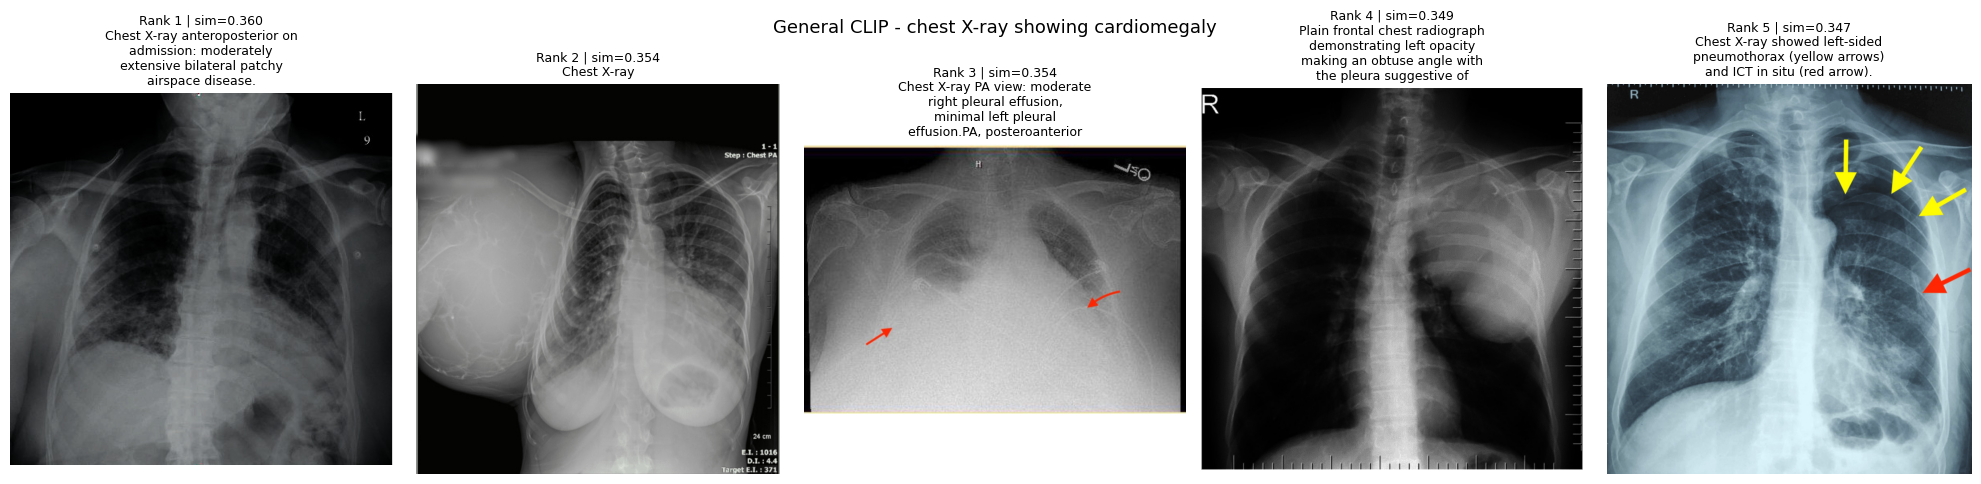

[(21,
  0.35979390144348145,
  'Chest X-ray anteroposterior on admission: moderately extensive bilateral patchy airspace disease.'),
 (22, 0.35410016775131226, 'Chest X-ray'),
 (14,
  0.35361170768737793,
  'Chest X-ray PA view: moderate right pleural effusion, minimal left pleural effusion.PA,\xa0posteroanterior'),
 (30,
  0.34881314635276794,
  'Plain frontal chest radiograph demonstrating left opacity making an obtuse angle with the pleura suggestive of pleural tumor'),
 (2,
  0.3470901846885681,
  'Chest X-ray showed left-sided pneumothorax (yellow arrows) and ICT in situ (red arrow).')]

In [ ]:
BASELINE_QUERY = "chest X-ray showing cardiomegaly"
show_retrieval(
    BASELINE_QUERY,
    clip_model,
    clip_tokenizer,
    clip_test_image_emb,
    k=5,
    title_prefix="General CLIP - ",
)

# Part F - Stage 2: Tiny medical fine-tuning of CLIP

## 18. What are we teaching here?

We are **not training CLIP from scratch**. We start with a pretrained general CLIP model and update its weights using only a tiny medical image-report set.

For one batch of `B` matching image-text pairs:

```text
                 TEXTS
             T0 T1 T2 ...
IMAGES   I0   +  -  -
         I1   -  +  -
         I2   -  -  +
```

The diagonal contains the correct pairs. CLIP-style contrastive learning encourages correct pairs to score higher than mismatched combinations.


## Highlight: Purpose of Tiny Fine-tuning

We are not aiming for state-of-the-art results here. This section is purely for demonstrating the *mechanism* of contrastive fine-tuning using a small, accessible dataset. It's about understanding the process, not optimizing performance yet.

## 19. Build the fine-tuning dataset and dataloader

The OpenAI CLIP text context is shorter than many radiology reports. The tokenizer truncates longer reports automatically. This is useful to mention as a real limitation of using general CLIP on medical narrative text.


In [ ]:
class MedicalPairDataset(Dataset):
    def __init__(self, rows, preprocess, tokenizer):
        self.rows = rows
        self.preprocess = preprocess
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        image_tensor = self.preprocess(row["image"])
        token_tensor = self.tokenizer([row["text"]])[0]
        return image_tensor, token_tensor


ft_dataset = MedicalPairDataset(ft_rows, clip_preprocess_train, clip_tokenizer)
ft_loader = DataLoader(
    ft_dataset,
    batch_size=FT_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    drop_last=True,
)

print("Fine-tuning batches per epoch:", len(ft_loader))

Fine-tuning batches per epoch: 8


## 20. STUDENT TASK - write the core contrastive-learning lines

Before revealing the next solution cell, attendees should write these operations themselves:

```python
image_features = model.encode_image(image_batch)
text_features  = model.encode_text(text_batch)

image_features = F.normalize(image_features, dim=-1)
text_features  = F.normalize(text_features, dim=-1)

logits = logit_scale * image_features @ text_features.T
labels = torch.arange(batch_size, device=device)

loss_i2t = F.cross_entropy(logits, labels)
loss_t2i = F.cross_entropy(logits.T, labels)
loss = (loss_i2t + loss_t2i) / 2

loss.backward()
optimizer.step()
```

This is the most important hands-on coding moment of the tutorial.


## Core Contrastive Learning

**STUDENT TASK:** This is the most important hands-on coding moment. Identify how the image and text features are encoded, normalized, and then used to compute the `logits` and the `cross_entropy` loss. Pay attention to how `loss.backward()` and `optimizer.step()` update the model weights.

In [ ]:
optimizer = torch.optim.AdamW(
    clip_model.parameters(),
    lr=FT_LR,
    weight_decay=FT_WEIGHT_DECAY,
)

use_amp = device.type == "cuda"
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
loss_history = []

print("Starting tiny medical fine-tuning...")
clip_model.train()

for epoch in range(FT_EPOCHS):
    epoch_losses = []

    for image_batch, text_batch in ft_loader:
        image_batch = image_batch.to(device)
        text_batch = text_batch.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            # STUDENT TASK / SOLUTION
            image_features = clip_model.encode_image(image_batch)
            text_features = clip_model.encode_text(text_batch)

            image_features = F.normalize(image_features.float(), dim=-1)
            text_features = F.normalize(text_features.float(), dim=-1)

            # CLIP learns a temperature/logit scale parameter.
            logit_scale = clip_model.logit_scale.exp().clamp(max=100)
            logits = logit_scale * (image_features @ text_features.T)

            labels = torch.arange(logits.shape[0], device=device)
            loss_i2t = F.cross_entropy(logits, labels)
            loss_t2i = F.cross_entropy(logits.T, labels)
            loss = (loss_i2t + loss_t2i) / 2

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(clip_model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_losses.append(float(loss.detach().cpu()))
        loss_history.append(float(loss.detach().cpu()))

    print(
        f"Epoch {epoch + 1}/{FT_EPOCHS} | "
        f"mean contrastive loss = {np.mean(epoch_losses):.4f}"
    )

clip_model.eval()
print("Fine-tuning demonstration complete.")

/tmp/ipykernel_874/619938948.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_874/619938948.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Starting tiny medical fine-tuning...
Epoch 1/2 | mean contrastive loss = 2.6245
Epoch 2/2 | mean contrastive loss = 2.0905
Fine-tuning demonstration complete.


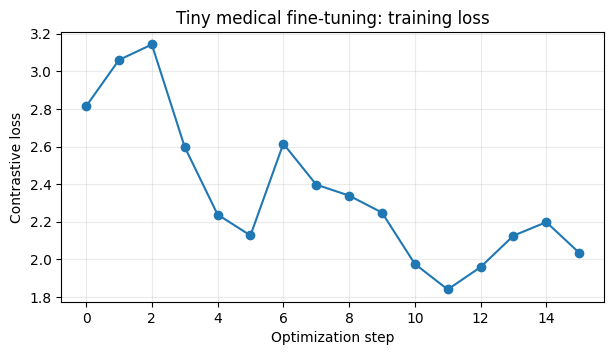

In [ ]:
plt.figure(figsize=(7, 3.5))
plt.plot(loss_history, marker="o")
plt.xlabel("Optimization step")
plt.ylabel("Contrastive loss")
plt.title("Tiny medical fine-tuning: training loss")
plt.grid(alpha=0.25)
plt.show()

## 21. Re-evaluate the fine-tuned CLIP model

The crucial rule: **do not evaluate on the 64 IU X-Ray training pairs.** We return to the same held-out ROCOv2 test examples used for the baseline.


In [ ]:
ft_clip_test_image_emb = encode_clip_images(clip_model, clip_preprocess_val, test_images)
ft_clip_test_text_emb = encode_clip_texts(clip_model, clip_tokenizer, test_captions)

ft_clip_metrics, ft_clip_sim = compute_retrieval_metrics(
    ft_clip_test_image_emb,
    ft_clip_test_text_emb,
    RECALL_K,
)

print("TINY MEDICAL FINE-TUNED CLIP")
for key, value in ft_clip_metrics.items():
    print(f"{key:>24}: {value:.4f}")

results.append(metrics_row("CLIP + tiny medical fine-tuning", ft_clip_metrics))

TINY MEDICAL FINE-TUNED CLIP
                 T2I_R@1: 0.0938
                 I2T_R@1: 0.0000
                 T2I_R@5: 0.2500
                 I2T_R@5: 0.2500
                T2I_R@10: 0.4062
                I2T_R@10: 0.4062
  mean_paired_similarity: 0.2387


## Highlight: Interpreting Fine-tuning Results

As noted the results of this tiny fine-tuning can vary significantly (improve, stay similar, or even worsen) due to the extremely small dataset and the difference in text styles between IU X-Ray and ROCOv2. The key is to understand *why* these outcomes are possible, not just the numerical values.

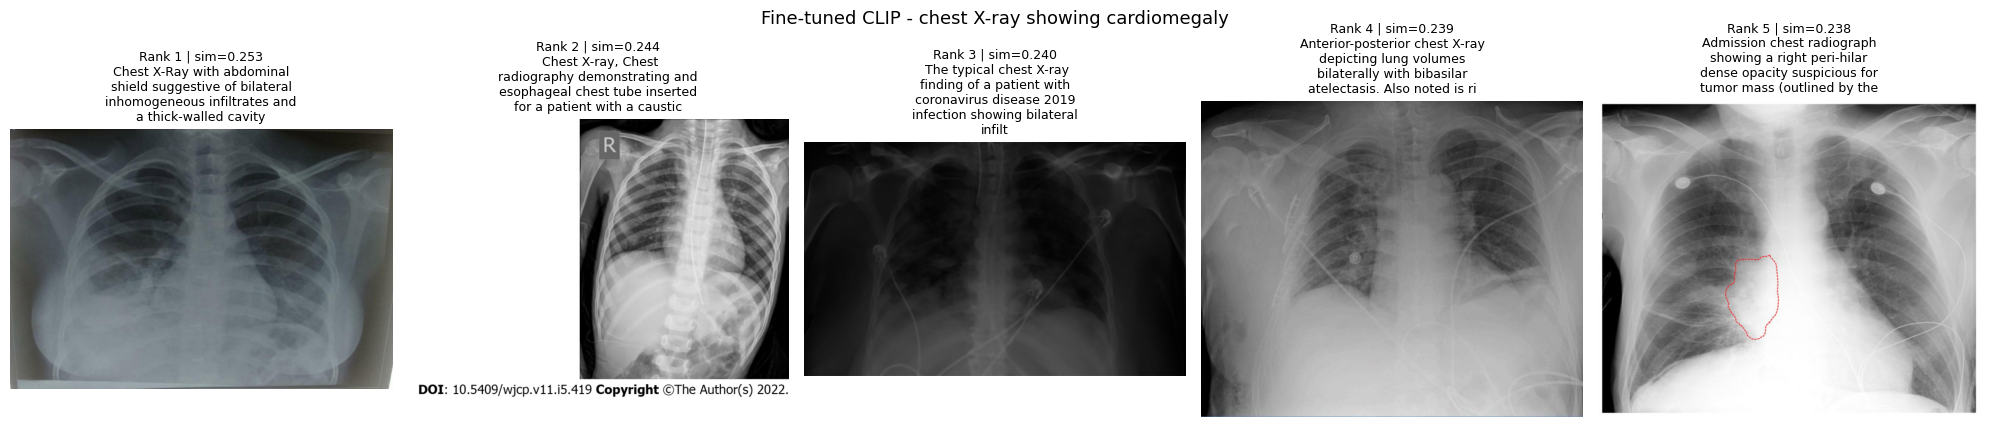

[(23,
  0.2525777220726013,
  'Chest X-Ray with abdominal shield suggestive of bilateral inhomogeneous infiltrates and a thick-walled cavity with air-fluid level in the lower zone of the right lung field.'),
 (19,
  0.24429374933242798,
  ' Chest X-ray, Chest radiography demonstrating and esophageal chest tube inserted for a patient with a caustic injury. '),
 (1,
  0.2402466982603073,
  ' The typical chest X-ray finding of a patient with coronavirus disease 2019 infection showing bilateral infiltration.'),
 (5,
  0.2393191158771515,
  'Anterior-posterior chest X-ray depicting lung volumes bilaterally with bibasilar atelectasis. Also noted is right lateral chest wall subcutaneous emphysema and right sided rib fixation hardware.'),
 (28,
  0.23809218406677246,
  'Admission chest radiograph showing a right peri-hilar dense opacity suspicious for tumor mass (outlined by the red dotted line) with surrounding subtle areas of lung atelectasis.')]

In [ ]:
show_retrieval(
    BASELINE_QUERY,
    clip_model,
    clip_tokenizer,
    ft_clip_test_image_emb,
    k=5,
    title_prefix="Fine-tuned CLIP - ",
)

### Important interpretation

With only 64 medical pairs and 2 epochs, the fine-tuned model may improve, stay similar, or become worse on the held-out ROCOv2 subset. **All three outcomes are educationally valid.**

Possible reasons include:

- the fine-tuning set is extremely small;
- IU X-Ray contains chest radiographs only;
- ROCOv2 captions come from biomedical literature and differ stylistically from radiology reports;
- a learning rate that is too high may over-specialize the model;
- domain adaptation can trade off generalization and specialization.

Do not promise attendees that tiny fine-tuning will always improve Recall@K.


# Part G - Stage 3: BiomedCLIP

## 22. Why BiomedCLIP is not just our tiny fine-tuned CLIP

Our previous stage used a handful of chest X-ray/report pairs only to demonstrate the mechanics of domain adaptation.

BiomedCLIP is a biomedical vision-language foundation model pretrained contrastively on **PMC-15M**, a collection of about 15 million biomedical figure-caption pairs. Its released configuration uses:

- ViT-B/16-style vision encoder;
- PubMedBERT-family biomedical text encoder;
- 224 x 224 image input;
- 256-token text context;
- 512-dimensional shared embedding space.

We now evaluate it on the **same held-out ROCOv2 test subset**.


In [ ]:
# Release the fine-tuned general CLIP from GPU before loading BiomedCLIP.
clip_model = clip_model.cpu()
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

BIOMED_MODEL_ID = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
BIOMED_CONTEXT_LENGTH = 256

print("Loading BiomedCLIP...")
t0 = time.perf_counter()

biomed_model, biomed_preprocess = create_model_from_pretrained(BIOMED_MODEL_ID)
biomed_tokenizer = get_tokenizer(BIOMED_MODEL_ID)
biomed_model = biomed_model.to(device)
biomed_model.eval()

print(f"BiomedCLIP loaded in {time.perf_counter() - t0:.1f} s")

Loading BiomedCLIP...


open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.13/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

BiomedCLIP loaded in 28.4 s


## Highlight: Introducing BiomedCLIP

BiomedCLIP is a model *designed* for the biomedical domain, pre-trained on a massive dataset (`PMC-15M`). Expect a significant performance jump compared to general CLIP, and likely even our tiny fine-tuned CLIP, because it inherently understands medical concepts and language much better.

In [ ]:
@torch.inference_mode()
def encode_biomed_images(model, preprocess, image_list, batch_size=16):
    model.eval()
    batches = []

    for start in range(0, len(image_list), batch_size):
        batch_images = image_list[start:start + batch_size]
        batch_tensor = torch.stack([preprocess(img) for img in batch_images]).to(device)
        features = model.encode_image(batch_tensor)
        features = F.normalize(features.float(), dim=-1)
        batches.append(features.cpu())

    return torch.cat(batches, dim=0)


@torch.inference_mode()
def encode_biomed_texts(model, tokenizer, text_list, batch_size=32):
    model.eval()
    batches = []

    for start in range(0, len(text_list), batch_size):
        batch_texts = text_list[start:start + batch_size]
        tokens = tokenizer(
            batch_texts,
            context_length=BIOMED_CONTEXT_LENGTH,
        ).to(device)
        features = model.encode_text(tokens)
        features = F.normalize(features.float(), dim=-1)
        batches.append(features.cpu())

    return torch.cat(batches, dim=0)

In [ ]:
print("Encoding the same held-out ROCOv2 test subset with BiomedCLIP...")
biomed_test_image_emb = encode_biomed_images(biomed_model, biomed_preprocess, test_images)
biomed_test_text_emb = encode_biomed_texts(biomed_model, biomed_tokenizer, test_captions)

print("Image embeddings:", tuple(biomed_test_image_emb.shape))
print("Text embeddings :", tuple(biomed_test_text_emb.shape))

biomed_metrics, biomed_sim = compute_retrieval_metrics(
    biomed_test_image_emb,
    biomed_test_text_emb,
    RECALL_K,
)

print("BIOMEDCLIP")
for key, value in biomed_metrics.items():
    print(f"{key:>24}: {value:.4f}")

results.append(metrics_row("BiomedCLIP", biomed_metrics))

Encoding the same held-out ROCOv2 test subset with BiomedCLIP...
Image embeddings: (32, 512)
Text embeddings : (32, 512)
BIOMEDCLIP
                 T2I_R@1: 0.5938
                 I2T_R@1: 0.5000
                 T2I_R@5: 0.8750
                 I2T_R@5: 0.9062
                T2I_R@10: 0.9375
                I2T_R@10: 0.9375
  mean_paired_similarity: 0.4363


## 23. BiomedCLIP retrieval example using the same query


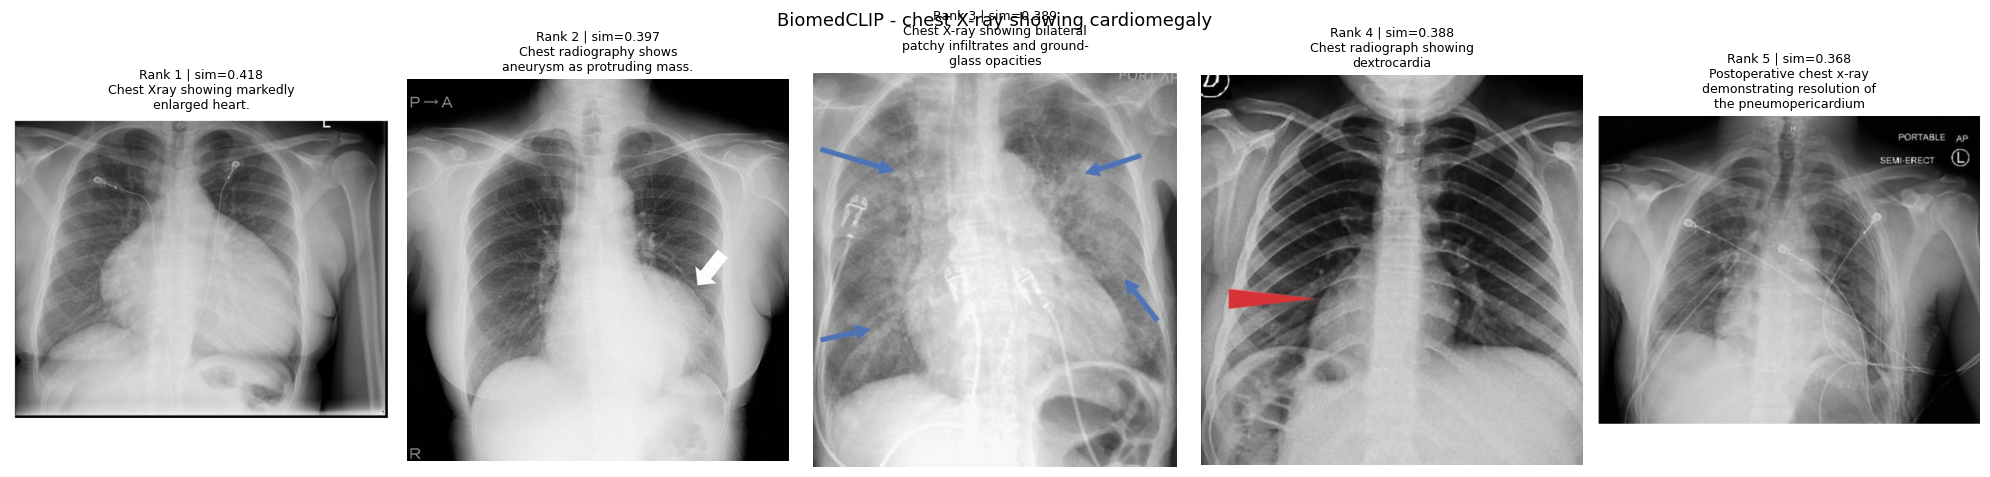

In [ ]:
@torch.inference_mode()
def search_with_biomedclip(query, k=5):
    query_emb = encode_biomed_texts(biomed_model, biomed_tokenizer, [query])
    similarities = query_emb @ biomed_test_image_emb.T
    scores, indices = similarities[0].topk(min(k, len(test_images)))
    return scores, indices


def show_biomed_results(query, k=5):
    scores, indices = search_with_biomedclip(query, k=k)
    fig, axes = plt.subplots(1, len(indices), figsize=(4 * len(indices), 4.8))
    axes = np.atleast_1d(axes)

    for rank, (ax, score, idx) in enumerate(zip(axes, scores, indices), start=1):
        idx = int(idx)
        ax.imshow(test_images[idx])
        ax.set_title(
            f"Rank {rank} | sim={float(score):.3f}\n" + textwrap.fill(test_captions[idx][:110], 30),
            fontsize=9,
        )
        ax.axis("off")

    plt.suptitle(f"BiomedCLIP - {query}", fontsize=13)
    plt.tight_layout()
    plt.show()


show_biomed_results(BASELINE_QUERY, k=5)

# Part H - Final comparison

## 24. Compare all three stages on the same held-out test set

The important comparison is not whether one individual query looks good. It is whether retrieval metrics and qualitative behavior change under the same evaluation conditions.


In [ ]:
results_df = pd.DataFrame(results)

ordered_cols = [
    "Model",
    "T2I_R@1", "T2I_R@5", "T2I_R@10",
    "I2T_R@1", "I2T_R@5", "I2T_R@10",
    "mean_paired_similarity",
]
results_df = results_df[ordered_cols]
results_df

,Model,T2I_R@1,T2I_R@5,T2I_R@10,I2T_R@1,I2T_R@5,I2T_R@10,mean_paired_similarity
0,General CLIP,0.09375,0.3125,0.37500,0.15625,0.28125,0.46875,0.333333
1,CLIP + tiny medical fine-tuning,0.09375,0.2500,0.40625,0.00000,0.25000,0.40625,0.238658
2,BiomedCLIP,0.59375,0.8750,0.93750,0.50000,0.90625,0.93750,0.436349


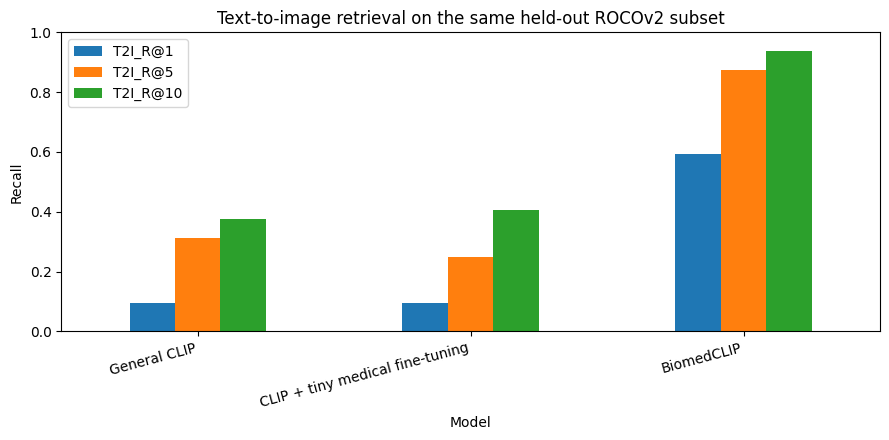

In [ ]:
plot_df = results_df.set_index("Model")[["T2I_R@1", "T2I_R@5", "T2I_R@10"]]
ax = plot_df.plot(kind="bar", figsize=(9, 4.5))
ax.set_ylabel("Recall")
ax.set_title("Text-to-image retrieval on the same held-out ROCOv2 subset")
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# Part I - Continue with ROCOv2: Interactive Cross-Modal Retrieval

## 25. From model comparison to a usable retrieval system

We have now evaluated three stages on the **same held-out ROCOv2 chest-radiograph test subset**:

1. General CLIP
2. CLIP + tiny medical fine-tuning
3. BiomedCLIP

The benchmark stage is complete. We now return to the broader **ROCOv2 dataset** and use the CLIP idea as an interactive retrieval system.

This section is deliberately separated from the earlier quantitative comparison:

```text
Earlier benchmark
-----------------
32 held-out chest-radiograph pairs
-> fair comparison of three models

Now: retrieval application
--------------------------
Broader ROCOv2 gallery
-> text query -> Top-K images
-> image query -> Top-K captions
```

For the application-style demo below, we use **BiomedCLIP** as the default retrieval encoder because it is the biomedical-domain CLIP model already loaded in memory. This does **not** change the earlier three-model results.


## 26. Build a broader ROCOv2 retrieval gallery

The earlier evaluation subset was intentionally restricted to chest radiographs so the three-model comparison stayed focused.

For interactive retrieval, we want a more varied gallery containing different radiology modalities and anatomical regions. We therefore stream a small teaching gallery from the ROCOv2 **training split**.

This gallery is **not used to recompute the three-model benchmark**. It is only used for the final retrieval demonstration.


## Highlight: Interactive Retrieval vs. Benchmark

This section is about applying what we've learned to a practical retrieval system. Note that we are now using a *broader* ROCOv2 gallery (from the training split) and are *not* recomputing the benchmark metrics. This part is for exploration, not quantitative comparison.

In [ ]:
ROCO_RETRIEVAL_SPLIT = "train"
ROCO_RETRIEVAL_SAMPLES = 64

print(
    f"Streaming {ROCO_RETRIEVAL_SAMPLES} ROCOv2 examples "
    f"from the {ROCO_RETRIEVAL_SPLIT!r} split for the retrieval gallery..."
)

roco_gallery_stream = load_dataset(
    ROCO_DATASET_ID,
    split=ROCO_RETRIEVAL_SPLIT,
    streaming=True,
)

roco_gallery_rows = list(
    itertools.islice(roco_gallery_stream, ROCO_RETRIEVAL_SAMPLES)
)

if not roco_gallery_rows:
    raise RuntimeError("No ROCOv2 retrieval-gallery examples were loaded.")

roco_gallery_images = [row["image"].convert("RGB") for row in roco_gallery_rows]
roco_gallery_captions = [row["caption"] for row in roco_gallery_rows]
roco_gallery_ids = [row["image_id"] for row in roco_gallery_rows]
roco_gallery_cuis = [row.get("cui", []) for row in roco_gallery_rows]

print("Retrieval gallery size:", len(roco_gallery_rows))
print("First gallery ID     :", roco_gallery_ids[0])
print("First gallery caption:", roco_gallery_captions[0])


Streaming 64 ROCOv2 examples from the 'train' split for the retrieval gallery...


Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Retrieval gallery size: 64
First gallery ID     : ROCOv2_2023_train_000001
First gallery caption: Head CT demonstrating left parotiditis.


## 27. Inspect a few gallery examples

Before retrieval, look at a few ROCOv2 records again. Unlike the 32-case evaluation subset, this gallery is not restricted to chest radiographs.


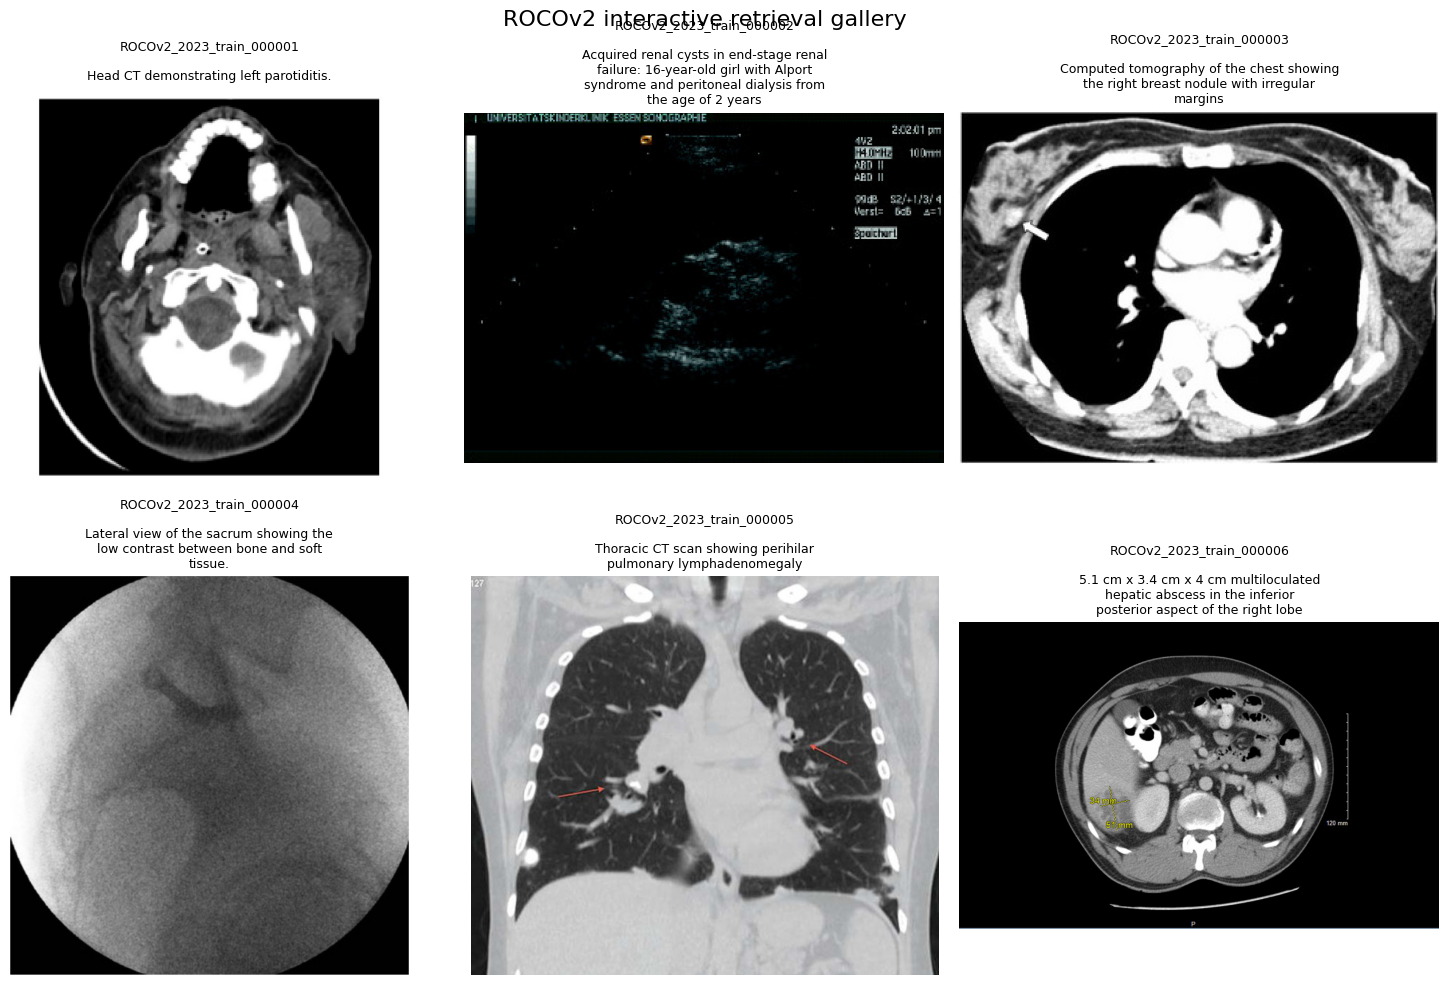

In [ ]:
N_GALLERY_SHOW = min(6, len(roco_gallery_images))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = np.asarray(axes).reshape(-1)

for i in range(len(axes)):
    ax = axes[i]
    if i >= N_GALLERY_SHOW:
        ax.axis("off")
        continue

    ax.imshow(roco_gallery_images[i])
    ax.axis("off")
    ax.set_title(
        f"{roco_gallery_ids[i]}\n\n"
        + textwrap.fill(roco_gallery_captions[i][:180], 40),
        fontsize=9,
    )

plt.suptitle("ROCOv2 interactive retrieval gallery", fontsize=16)
plt.tight_layout()
plt.show()


## 28. Encode the ROCOv2 gallery once with BiomedCLIP

Retrieval becomes fast if the gallery is encoded **once** and the embeddings are reused for every query.

```text
64 ROCOv2 images  -> BiomedCLIP image encoder -> stored image embeddings
64 ROCOv2 captions -> BiomedCLIP text encoder -> stored text embeddings
```

After this cell, a new text query only needs to be encoded once and compared with the stored image vectors.


In [ ]:
print("Encoding the ROCOv2 retrieval gallery with BiomedCLIP...")

t0 = time.perf_counter()

roco_gallery_image_emb = encode_biomed_images(
    biomed_model,
    biomed_preprocess,
    roco_gallery_images,
)

roco_gallery_text_emb = encode_biomed_texts(
    biomed_model,
    biomed_tokenizer,
    roco_gallery_captions,
)

print("Gallery image embeddings:", tuple(roco_gallery_image_emb.shape))
print("Gallery text embeddings :", tuple(roco_gallery_text_emb.shape))
print(f"Gallery encoding time   : {time.perf_counter() - t0:.1f} s")


Encoding the ROCOv2 retrieval gallery with BiomedCLIP...
Gallery image embeddings: (64, 512)
Gallery text embeddings : (64, 512)
Gallery encoding time   : 88.7 s


## Highlight: Efficient Gallery Encoding

Notice that we encode the entire ROCOv2 gallery *once*. This is crucial for performance. In a real application, you wouldn't re-encode the entire gallery for every single query. Instead, you'd store these embeddings and perform fast similarity searches against them.

# Part J - ROCOv2 Text -> Image Retrieval

## 29. Give a medical text query and retrieve the Top-K images

The retrieval logic is the same idea used earlier:

```python
query_embedding = encode_text(query)
similarities = query_embedding @ image_embeddings.T
scores, indices = similarities.topk(k)
```

Because the vectors are normalized, the dot product acts as cosine similarity.


In [ ]:
@torch.inference_mode()
def roco_text_to_image(query, k=5):
    """Return the Top-K ROCOv2 gallery images for a natural-language query."""
    k = min(k, len(roco_gallery_images))

    query_embedding = encode_biomed_texts(
        biomed_model,
        biomed_tokenizer,
        [query],
    )

    # STUDENT TASK: compare one text vector with all stored image vectors.
    similarities = query_embedding @ roco_gallery_image_emb.T
    scores, indices = similarities[0].topk(k)

    return scores, indices


def show_roco_text_to_image(query, k=5):
    scores, indices = roco_text_to_image(query, k=k)

    fig, axes = plt.subplots(1, len(indices), figsize=(4 * len(indices), 4.8))
    axes = np.atleast_1d(axes)

    print(f"Text query: {query}\n")

    results = []
    for rank, (ax, score, idx) in enumerate(zip(axes, scores, indices), start=1):
        idx = int(idx)
        score = float(score)

        ax.imshow(roco_gallery_images[idx])
        ax.axis("off")
        ax.set_title(
            f"Rank {rank} | sim={score:.3f}\n"
            + textwrap.fill(roco_gallery_captions[idx][:120], 31),
            fontsize=9,
        )

        results.append({
            "rank": rank,
            "image_id": roco_gallery_ids[idx],
            "similarity": score,
            "caption": roco_gallery_captions[idx],
        })

    plt.suptitle(f"ROCOv2 text -> image retrieval: {query}", fontsize=13)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(results)


## 30. Guided text-query examples

These queries are useful starting points because the early ROCOv2 training records contain varied CT/MRI/X-ray findings. The exact ranking is produced by the model at runtime.


Text query: head CT demonstrating left parotiditis



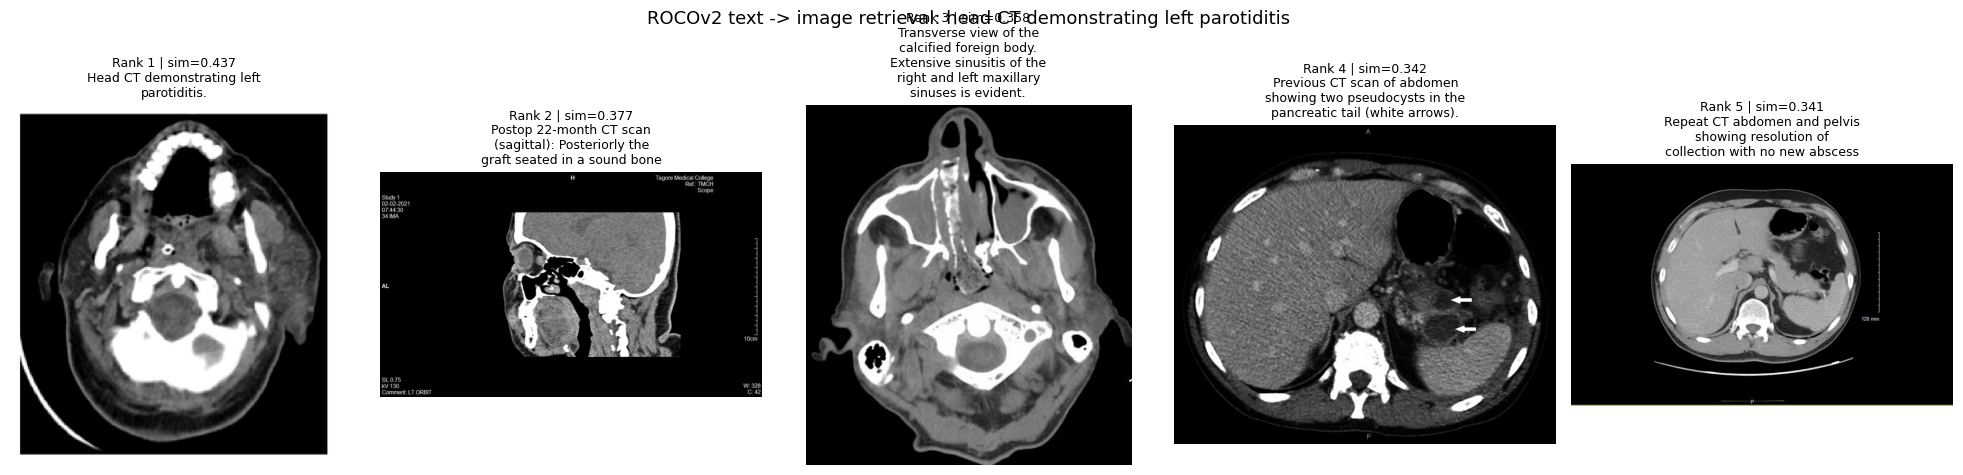

,rank,image_id,similarity,caption
0,1,ROCOv2_2023_train_000001,0.436554,Head CT demonstrating left parotiditis.
1,2,ROCOv2_2023_train_000011,0.377082,Postop 22-month CT scan (sagittal): Posteriorly the graft seated in a sound bone
2,3,ROCOv2_2023_train_000031,0.357672,Transverse view of the calcified foreign body. Extensive sinusitis of the right and left maxillary sinuses is evident.
3,4,ROCOv2_2023_train_000026,0.342192,Previous CT scan of abdomen showing two pseudocysts in the pancreatic tail (white arrows).
4,5,ROCOv2_2023_train_000007,0.340846,Repeat CT abdomen and pelvis showing resolution of collection with no new abscess


In [ ]:
show_roco_text_to_image(
    "head CT demonstrating left parotiditis",
    k=5,
)


Text query: CT of the chest showing a breast nodule with irregular margins



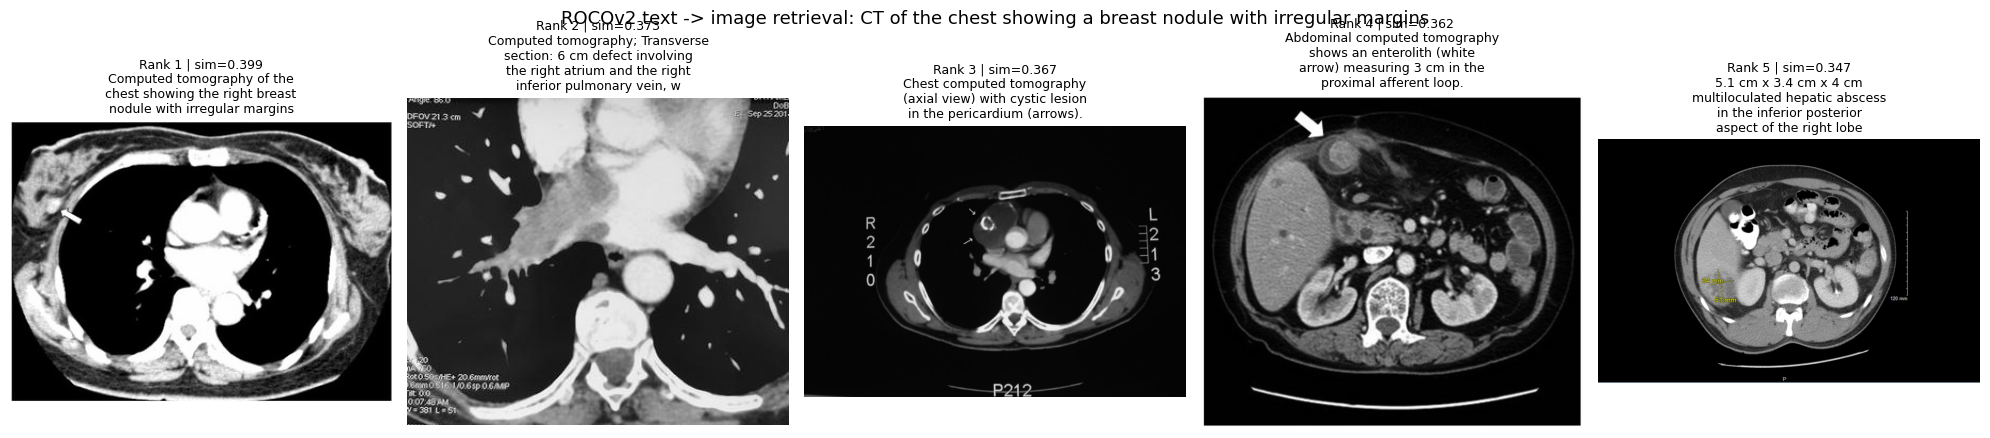

,rank,image_id,similarity,caption
0,1,ROCOv2_2023_train_000003,0.399221,Computed tomography of the chest showing the right breast nodule with irregular margins
1,2,ROCOv2_2023_train_000062,0.373290,"Computed tomography; Transverse section: 6 cm defect involving the right atrium and the right inferior pulmonary vein, which appears markedly enlarged"
2,3,ROCOv2_2023_train_000058,0.367036,Chest computed tomography (axial view) with cystic lesion in the pericardium (arrows).
3,4,ROCOv2_2023_train_000051,0.361535,Abdominal computed tomography shows an enterolith (white arrow) measuring 3 cm in the proximal afferent loop.
4,5,ROCOv2_2023_train_000006,0.346937,5.1 cm x 3.4 cm x 4 cm multiloculated hepatic abscess in the inferior posterior aspect of the right lobe


In [ ]:
show_roco_text_to_image(
    "CT of the chest showing a breast nodule with irregular margins",
    k=5,
)


Text query: brain MRI showing hyperintense abnormalities in the basal ganglia



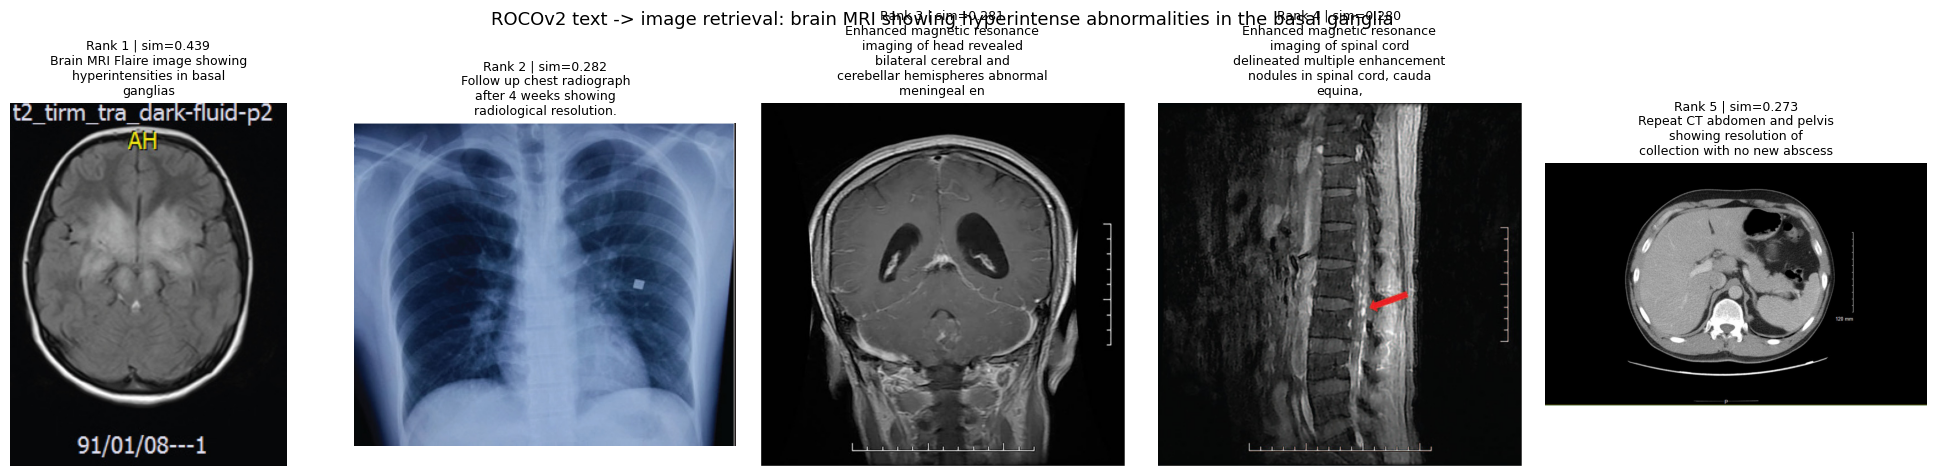

,rank,image_id,similarity,caption
0,1,ROCOv2_2023_train_000050,0.439380,Brain MRI Flaire image showing hyperintensities in basal ganglias
1,2,ROCOv2_2023_train_000034,0.282330,Follow up chest radiograph after 4 weeks showing radiological resolution.
2,3,ROCOv2_2023_train_000012,0.280674,Enhanced magnetic resonance imaging of head revealed bilateral cerebral and cerebellar hemispheres abnormal meningeal enhancement.
3,4,ROCOv2_2023_train_000013,0.280278,"Enhanced magnetic resonance imaging of spinal cord delineated multiple enhancement nodules in spinal cord, cauda equina, and cristae membrane (arrow)."
4,5,ROCOv2_2023_train_000007,0.273243,Repeat CT abdomen and pelvis showing resolution of collection with no new abscess


In [ ]:
show_roco_text_to_image(
    "brain MRI showing hyperintense abnormalities in the basal ganglia",
    k=5,
)


## 31. STUDENT TASK - write your own medical query

Change the text below and also experiment with `TOP_K`.

Try varying:

- modality: `CT`, `MRI`, `X-ray`, `ultrasound`;
- anatomy: `brain`, `chest`, `liver`, `spine`, `kidney`;
- finding: `nodule`, `effusion`, `abscess`, `fracture`, `enlargement`;
- specificity: compare a short term with a detailed radiology-style description.


Text query: chest CT showing ground-glass opacities and pleural effusion



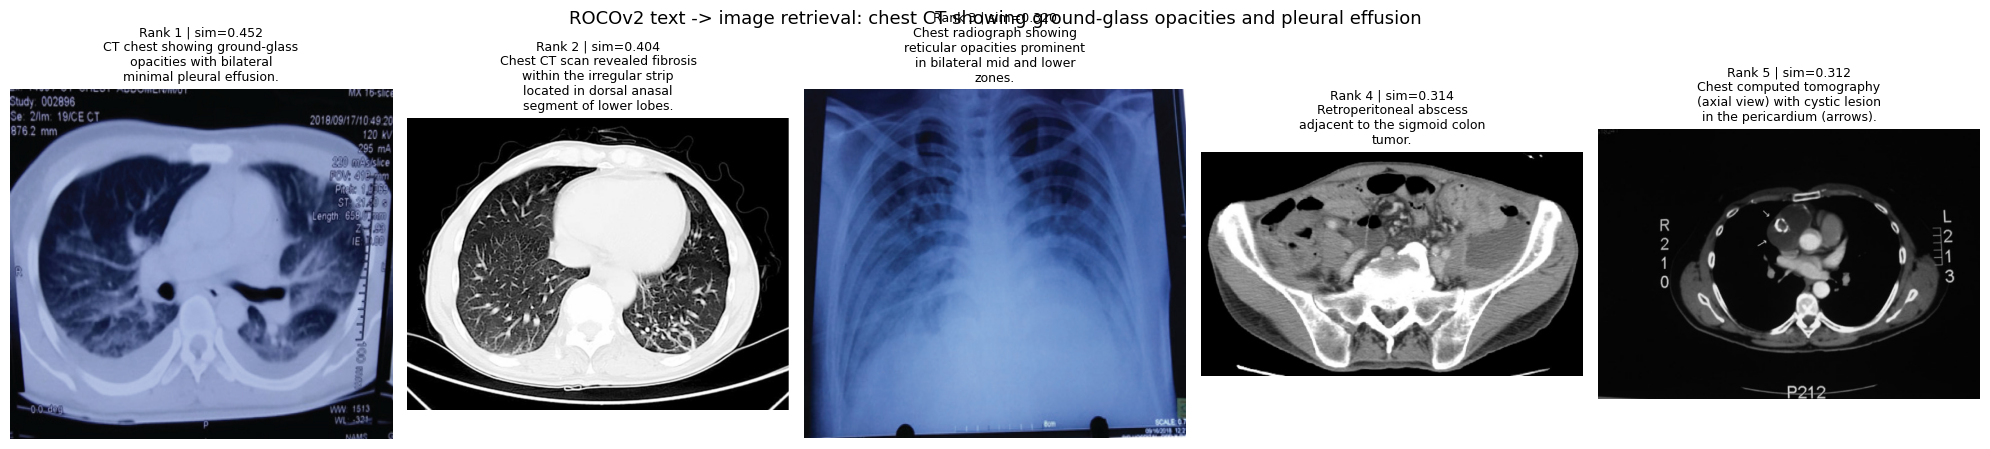

,rank,image_id,similarity,caption
0,1,ROCOv2_2023_train_000033,0.452077,CT chest showing ground-glass opacities with bilateral minimal pleural effusion.
1,2,ROCOv2_2023_train_000028,0.403678,Chest CT scan revealed fibrosis within the irregular strip located in dorsal anasal segment of lower lobes.
2,3,ROCOv2_2023_train_000032,0.319754,Chest radiograph showing reticular opacities prominent in bilateral mid and lower zones.
3,4,ROCOv2_2023_train_000044,0.314229,Retroperitoneal abscess adjacent to the sigmoid colon tumor.
4,5,ROCOv2_2023_train_000058,0.312120,Chest computed tomography (axial view) with cystic lesion in the pericardium (arrows).


In [ ]:
MY_ROCO_QUERY = "chest CT showing ground-glass opacities and pleural effusion"
TOP_K = 5

my_text_to_image_results = show_roco_text_to_image(
    MY_ROCO_QUERY,
    k=TOP_K,
)

my_text_to_image_results


# Part K - ROCOv2 Image -> Text Retrieval

## 32. Reverse the direction: image query -> Top-K captions

Because image and text embeddings live in the same shared space, we can reverse the search without training another model.

```text
query image
    ↓
its stored image embedding
    ↓
compare with every stored caption embedding
    ↓
Top-K textual descriptions
```

For this teaching gallery, the caption at the same index is the original paired caption. Other captions can still be semantically relevant.


In [ ]:
@torch.inference_mode()
def roco_image_to_text(image_index, k=5):
    """Retrieve the Top-K ROCOv2 captions for one gallery image."""
    if not 0 <= image_index < len(roco_gallery_images):
        raise IndexError(
            f"image_index must be between 0 and {len(roco_gallery_images) - 1}."
        )

    k = min(k, len(roco_gallery_captions))
    query_embedding = roco_gallery_image_emb[image_index:image_index + 1]

    # STUDENT TASK: compare one image vector with all stored text vectors.
    similarities = query_embedding @ roco_gallery_text_emb.T
    scores, indices = similarities[0].topk(k)

    return scores, indices


def show_roco_image_to_text(image_index, k=5):
    scores, indices = roco_image_to_text(image_index, k=k)

    plt.figure(figsize=(5, 5))
    plt.imshow(roco_gallery_images[image_index])
    plt.axis("off")
    plt.title(
        f"Query image: {roco_gallery_ids[image_index]}\n"
        + textwrap.fill(roco_gallery_captions[image_index][:110], 42),
        fontsize=10,
    )
    plt.show()

    print("Original paired caption:")
    print(roco_gallery_captions[image_index])
    print("\nTop retrieved captions:\n")

    results = []
    for rank, (score, idx) in enumerate(zip(scores, indices), start=1):
        idx = int(idx)
        score = float(score)
        paired = idx == image_index
        marker = " <-- original paired caption" if paired else ""

        print(
            f"{rank:>2}. sim={score:.3f} | "
            f"{roco_gallery_captions[idx]}{marker}"
        )

        results.append({
            "rank": rank,
            "caption_index": idx,
            "similarity": score,
            "is_original_pair": paired,
            "caption": roco_gallery_captions[idx],
        })

    return pd.DataFrame(results)


## Highlight: Bidirectional Retrieval

Because both images and text are embedded into the same shared semantic space, we can perform retrieval in *both* directions: text-to-image and image-to-text. This flexibility is a powerful feature of contrastive learning models like CLIP.

## 33. Run an image-to-text search

Change `IMAGE_QUERY_INDEX` to another gallery index from `0` to `ROCO_RETRIEVAL_SAMPLES - 1` and inspect how the retrieved captions change.


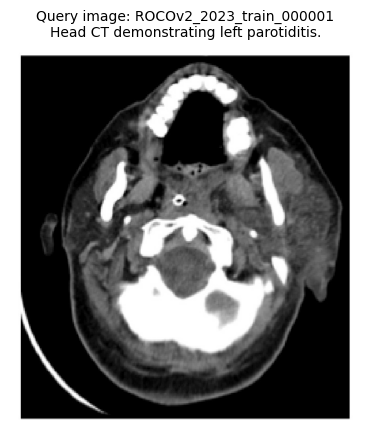

Original paired caption:
Head CT demonstrating left parotiditis.

Top retrieved captions:

 1. sim=0.495 | Head CT demonstrating left parotiditis. <-- original paired caption
 2. sim=0.378 | Radiological image (axial cuts)Axial cut, soft tissue window contrast computed tomography of the neck showing a heterogeneously enhancing lesion of both sides of the supraglottis extending to the right pyriform sinus (lower arrow) invading the thyroid cartilage (upper arrow).
 3. sim=0.373 | Transverse view of the calcified foreign body. Extensive sinusitis of the right and left maxillary sinuses is evident.
 4. sim=0.363 | CT demonstrating partially obstructed airway.CT: computed tomography.
 5. sim=0.354 | Abnormal air accumulation in the subcutaneous space of the left thigh.


,rank,caption_index,similarity,is_original_pair,caption
0,1,0,0.495251,True,Head CT demonstrating left parotiditis.
1,2,55,0.377537,False,"Radiological image (axial cuts)Axial cut, soft tissue window contrast computed tomography of the neck showing a heterogeneously enhancing lesion of both sides of the supraglottis extending to the right pyriform sinus..."
2,3,30,0.372987,False,Transverse view of the calcified foreign body. Extensive sinusitis of the right and left maxillary sinuses is evident.
3,4,14,0.362979,False,CT demonstrating partially obstructed airway.CT: computed tomography.
4,5,44,0.354239,False,Abnormal air accumulation in the subcutaneous space of the left thigh.


In [ ]:
IMAGE_QUERY_INDEX = 0
TOP_K_TEXT = 5

my_image_to_text_results = show_roco_image_to_text(
    IMAGE_QUERY_INDEX,
    k=TOP_K_TEXT,
)

my_image_to_text_results


## 34. What attendees should notice

The same BiomedCLIP representation now supports **both retrieval directions**:

```text
Text -> Image
"brain MRI showing ..."
        ↓
Top-K ROCOv2 images

Image -> Text
ROCOv2 query image
        ↓
Top-K ROCOv2 captions
```

Key discussion points:

1. The query does not have to exactly copy a stored caption.
2. More than one image or caption may be semantically relevant.
3. Similarity is semantic, not a guarantee of clinical correctness.
4. The original paired caption may not always rank first.
5. With only 64 gallery items, exhaustive matrix multiplication is enough; a large production collection would normally use a vector-search index.


## 35. Discussion questions

1. Did tiny medical fine-tuning improve or hurt the held-out ROCOv2 retrieval metrics?
2. Which model performs best on this small test subset?
3. Why is 64-pair fine-tuning **not** equivalent to large-scale biomedical pretraining?
4. IU X-Ray reports and ROCOv2 figure captions are both medical text, but are they written in the same style?
5. Why can an exact-pair metric mark a medically relevant alternative image as incorrect?
6. What could happen if the fine-tuning learning rate were much higher?
7. What would you change for a serious research benchmark (larger test set, repeated seeds, validation tuning, deduplication, confidence intervals)?


## Highlight: Key Discussion Points

Take time to review the discussion questions in the following cell (`26a5f86a`). These questions are designed to solidify your understanding of the entire tutorial, covering aspects from data splitting to model behavior and the nuances of evaluation.

## 36. Save the experiment outputs (optional)

The metrics and tiny fine-tuned checkpoint can be saved after the session. The checkpoint is for demonstration only.


In [ ]:
results_df.to_csv("clip_medical_domain_adaptation_results.csv", index=False)

torch.save(
    {
        "model_name": "ViT-B-16",
        "pretrained": "openai",
        "state_dict": clip_model.state_dict(),
        "fine_tune_pairs": FT_SAMPLES,
        "epochs": FT_EPOCHS,
        "learning_rate": FT_LR,
    },
    "tiny_medical_finetuned_clip.pt",
)

print("Saved:")
print("- clip_medical_domain_adaptation_results.csv")
print("- tiny_medical_finetuned_clip.pt")

Saved:
- clip_medical_domain_adaptation_results.csv
- tiny_medical_finetuned_clip.pt


# Part L - Final takeaway

```text
GENERAL CLIP
    |
    |  baseline on unseen medical data
    v
TINY MEDICAL FINE-TUNING
    |
    |  show contrastive loss + backpropagation
    v
FINE-TUNED CLIP
    |
    |  re-test on exactly the same unseen data
    v
BIOMEDCLIP
    |
    |  purpose-built biomedical vision-language model
    v
COMPARE RETRIEVAL RESULTS
    |
    v
ROCOv2 INTERACTIVE RETRIEVAL
    |
    |  text -> image and image -> text
    v
TOP-K SEMANTIC RESULTS
```

The tutorial demonstrates a progression from a **general foundation model**, through **small-scale domain adaptation**, to a **large-scale biomedical vision-language model**, and finally uses the shared embedding space for interactive ROCOv2 text-to-image and image-to-text retrieval.

The central methodological rule is simple: **all model comparisons use the same held-out test examples.**
